# Description

In this notebook, I will
- Load the code
- Create feature embedding 
- Train classifier model

In [1]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch 
import torch.nn as nn
import transformers
from transformers import AutoTokenizer, AutoModel

# 1. Load dataset

In [2]:
PATH_CSV_HUMAN_EVAL_GPT = "data/generated/human_eval_generated_gpt4o.csv"
PATH_CSV_HUMAN_EVAL_DEEPSEEK = "data/generated/human_eval_generated_deepseek.csv"
PATH_CSV_HUMAN_EVAL_LLAMA = "data/generated/human_eval_generated_llama.csv"
PATH_CSV_HUMAN_EVAL_QWEN = "data/generated/human_eval_generated_qwen.csv"

In [3]:
df_deepseek = pd.read_csv(PATH_CSV_HUMAN_EVAL_DEEPSEEK)
df_llama = pd.read_csv(PATH_CSV_HUMAN_EVAL_LLAMA)
df_qwen = pd.read_csv(PATH_CSV_HUMAN_EVAL_QWEN)
df_gpt = pd.read_csv(PATH_CSV_HUMAN_EVAL_GPT)

# combine all dataframes
df = pd.concat([df_deepseek, df_llama, df_qwen, df_gpt], ignore_index=True)
df = df.drop_duplicates()
df = df.reset_index(drop=True)

print("Dataframe shape:", df.shape)
df.sample()

Dataframe shape: (628, 7)


,description,generated_code,test_case,entry_point,total_asserts,passed_asserts,percentage
126,\ndef is_sorted(lst):\n '''\n Given a li...,def is_sorted(lst):\n for i in range(len(ls...,def check(candidate):\n\n # Check some simp...,is_sorted,13,12,0.923077


# 2. Construct dataset

Label is percent of test cases passed

In [4]:
idx = np.random.randint(0, df.shape[0])
gen_code = df.loc[idx, 'generated_code']
test_case = df.loc[idx, 'test_case']
entry_point = df.loc[idx, 'entry_point']

label = df.loc[idx, 'percentage']

print("Generated code:")
print(gen_code)
print("\nTest case:")
print(test_case)

if label == 1.0:
    print("\n[PASS]")
elif 0 < label < 1.0:
    print("\n[PARTIAL PASS]")
else:
    print("\n[FAIL]")

Generated code:
def even_odd_palindrome(n):
    def is_palindrome(num):
        return str(num) == str(num)[::-1]

    even_count = 0
    odd_count = 0

    for i in range(1, n+1):
        if is_palindrome(i):
            if i % 2 == 0:
                even_count += 1
            else:
                odd_count += 1

    return (even_count, odd_count)

Test case:
def check(candidate):

    # Check some simple cases
    assert candidate(123) == (8, 13)
    assert candidate(12) == (4, 6)
    assert candidate(3) == (1, 2)
    assert candidate(63) == (6, 8)
    assert candidate(25) == (5, 6)
    assert candidate(19) == (4, 6)
    assert candidate(9) == (4, 5), "This prints if this assert fails 1 (good for debugging!)"

    # Check some edge cases that are easy to work out by hand.
    assert candidate(1) == (0, 1), "This prints if this assert fails 2 (also good for debugging!)"



[PASS]


## 2.1. Perform code embedding

In [5]:
# Load model + tokenizer
model_name = "microsoft/codebert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

In [6]:
def embed_code(code_snippet: str):
    # Tokenize input
    inputs = tokenizer(code_snippet, return_tensors="pt", truncation=True, padding=True)
    
    # Get model outputs
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Use CLS token embedding as the vector
    embeddings = outputs.last_hidden_state[:, 0, :]
    return embeddings.squeeze().numpy()

In [7]:
df.sample()

,description,generated_code,test_case,entry_point,total_asserts,passed_asserts,percentage
204,"\n\ndef triples_sum_to_zero(l: list):\n """"""...","def triples_sum_to_zero(l: list):\n """"""\n ...",\n\nMETADATA = {}\n\n\ndef check(candidate):\n...,triples_sum_to_zero,9,9,1.0


In [8]:
list_code_embeddings = []
list_test_embeddings = []
list_labels = []

for i in range(df.shape[0]):
    
    # Positive sample
    code_script = df.loc[i, 'generated_code']
    test_case_script = df.loc[i, 'test_case']
    
    code_embedding = embed_code(code_script)
    test_embedding = embed_code(test_case_script)
    label = df.loc[i, 'percentage']
    if label > 0.5:
        label = 1.0
    else:
        label = 0.0

    list_code_embeddings.append(code_embedding)
    list_test_embeddings.append(test_embedding)
    list_labels.append(label)
    
    # To create negative sample, randomly select n test embedding from another code snippet
    n_neg_samples = 1
    for _ in range(n_neg_samples):
        rand_idx = np.random.randint(0, df.shape[0])
        while rand_idx == i:
            rand_idx = np.random.randint(0, df.shape[0])
        neg_test_case_script = df.loc[rand_idx, 'test_case']
        neg_test_embedding = embed_code(neg_test_case_script)
        
        list_code_embeddings.append(code_embedding)
        list_test_embeddings.append(neg_test_embedding)
        list_labels.append(0.0)
    
X_code = np.array(list_code_embeddings)
X_test =  np.array(list_test_embeddings)
y = np.array(list_labels)

print(f"Shape of code embeddings: {X_code.shape}")
print(f"Shape of test embeddings: {X_test.shape}")
print(f"Shape of labels: {y.shape}")

Shape of code embeddings: (1256, 768)
Shape of test embeddings: (1256, 768)
Shape of labels: (1256,)


In [9]:
# Number of samples per class
unique, counts = np.unique(y, return_counts=True)
class_distribution = dict(zip(unique, counts))
print("Class distribution (label: count):")
for label, count in class_distribution.items():
    print(f"  {label}: {count}")

Class distribution (label: count):
  0.0: 689
  1.0: 567


## 2.2. Balance dataset

In [10]:
# Duplicate minority class to balance dataset
minority_class = 1.0 if class_distribution[1.0] < class_distribution[0.0] else 0.0
num_to_add = abs(class_distribution[1.0] - class_distribution[0.0])
print(f"Duplicating {num_to_add} samples of class {minority_class} to balance dataset.")

Duplicating 122 samples of class 1.0 to balance dataset.


In [11]:
# perform duplication
indices_to_duplicate = np.where(y == minority_class)[0]
dup_code_embeddings = []
dup_test_embeddings = []
dup_labels = []
for i in range(num_to_add):
    idx = indices_to_duplicate[i % len(indices_to_duplicate)]
    dup_code_embeddings.append(X_code[idx])
    dup_test_embeddings.append(X_test[idx])
    dup_labels.append(y[idx])
    
X_code = np.vstack([X_code, np.array(dup_code_embeddings)])
X_test = np.vstack([X_test, np.array(dup_test_embeddings)])
y = np.hstack([y, np.array(dup_labels)])
print(f"New shape of code embeddings: {X_code.shape}")
print(f"New shape of test embeddings: {X_test.shape}")
print(f"New shape of labels: {y.shape}")

New shape of code embeddings: (1378, 768)
New shape of test embeddings: (1378, 768)
New shape of labels: (1378,)


# 3. Define model

In [21]:
class CodeEvalModel(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(CodeEvalModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(input_dim, hidden_dim)
        self.scale1 = nn.Parameter(torch.FloatTensor([0.5]))
        self.scale2 = nn.Parameter(torch.FloatTensor([0.5]))
        self.relu = nn.ReLU()
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)
        
    def forward(self, code_embedd, test_embedd):
        x_c = self.fc1(code_embedd)
        x_c = self.relu(x_c)
        x_c = self.dropout(x_c)
        
        x_t = self.fc2(test_embedd)
        x_t = self.relu(x_t)
        x_t = self.dropout(x_t)
        
        x = self.scale1 * x_c + self.scale2 * x_t
        x = self.fc3(x)
        return x

In [22]:
# Define model with hyperparameters
input_dim = X_code.shape[1]
hidden_dim = 128

model = CodeEvalModel(input_dim, hidden_dim)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters in model: {total_params}")
print(model)

Total parameters in model: 196995
CodeEvalModel(
  (fc1): Linear(in_features=768, out_features=128, bias=True)
  (fc2): Linear(in_features=768, out_features=128, bias=True)
  (relu): ReLU()
  (fc3): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
  (dropout): Dropout(p=0.2, inplace=False)
)


In [23]:
# Prepare data for training
from torch.utils.data import DataLoader, TensorDataset, random_split
tensor_X_code = torch.tensor(X_code, dtype=torch.float32)
tensor_X_test = torch.tensor(X_test, dtype=torch.float32)
tensor_y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

In [24]:
# Train-validation-test split
dataset = TensorDataset(tensor_X_code, tensor_X_test, tensor_y)
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

In [25]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 4. Training 

In [26]:
# Training process
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 20

criterion = nn.BCEWithLogitsLoss()

In [27]:
# Define training and evaluation loops
def train(model, loader, criterion, optimizer, device='cuda'): 
    model.train()
    running_loss = 0.0
    for code_embedd, test_embedd, labels in loader:
        optimizer.zero_grad()
        outputs = model(code_embedd, test_embedd)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * code_embedd.size(0)
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    with torch.no_grad():
        for code_embedd, test_embedd, labels in loader:
            outputs = model(code_embedd, test_embedd)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * code_embedd.size(0)
            preds = (outputs >= 0.5).float()
            correct += (preds == labels).sum().item()
    epoch_loss = running_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return epoch_loss, accuracy

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss = train(model, train_loader, criterion, optimizer)
    val_loss, val_accuracy = evaluate(model, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

Epoch 1/20, Train Loss: 0.6997, Val Loss: 0.6890, Val Acc: 0.5109
Epoch 2/20, Train Loss: 0.6947, Val Loss: 0.6891, Val Acc: 0.5109
Epoch 3/20, Train Loss: 0.7043, Val Loss: 0.6955, Val Acc: 0.5109
Epoch 4/20, Train Loss: 0.6885, Val Loss: 0.6939, Val Acc: 0.5109
Epoch 5/20, Train Loss: 0.6936, Val Loss: 0.6893, Val Acc: 0.5109
Epoch 6/20, Train Loss: 0.6873, Val Loss: 0.6904, Val Acc: 0.5109
Epoch 7/20, Train Loss: 0.6863, Val Loss: 0.6913, Val Acc: 0.5109
Epoch 8/20, Train Loss: 0.6864, Val Loss: 0.6920, Val Acc: 0.5109
Epoch 9/20, Train Loss: 0.6856, Val Loss: 0.6916, Val Acc: 0.5109
Epoch 10/20, Train Loss: 0.6861, Val Loss: 0.6911, Val Acc: 0.5109
Epoch 11/20, Train Loss: 0.6868, Val Loss: 0.6914, Val Acc: 0.5109
Epoch 12/20, Train Loss: 0.6853, Val Loss: 0.6911, Val Acc: 0.5109
Epoch 13/20, Train Loss: 0.6869, Val Loss: 0.6973, Val Acc: 0.5109
Epoch 14/20, Train Loss: 0.6846, Val Loss: 0.6913, Val Acc: 0.5109
Epoch 15/20, Train Loss: 0.6849, Val Loss: 0.6920, Val Acc: 0.5109
Epoc

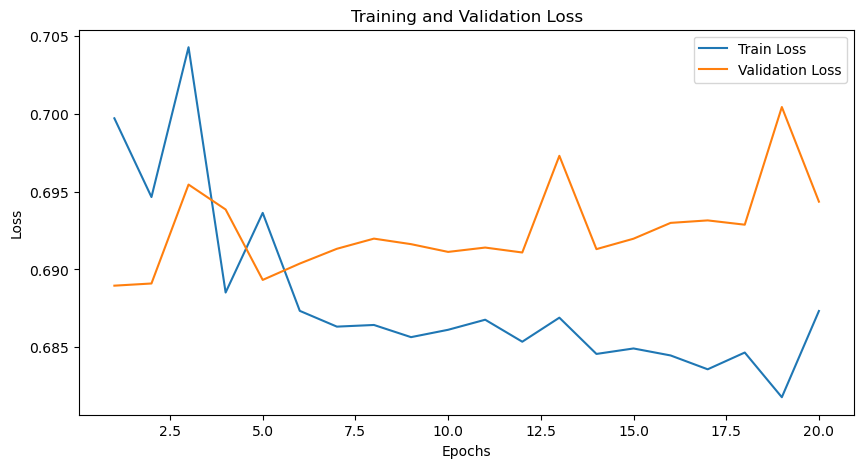

In [28]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [29]:
# Evaluate on test set
model.eval()
test_running_loss = 0.0
with torch.no_grad():
    for code_embedd, test_embedd, labels in test_loader:
        outputs = model(code_embedd, test_embedd)
        loss = criterion(outputs, labels)
        test_running_loss += loss.item() * code_embedd.size(0)
test_loss = test_running_loss / len(test_loader.dataset)
print(f"Test Loss: {test_loss:.4f}")

test_accuracy = 0.0
with torch.no_grad():
    correct = 0
    total = 0
    for code_embedd, test_embedd, labels in test_loader:
        outputs = model(code_embedd, test_embedd)
        predicted = (outputs >= 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.6883
Test Accuracy: 0.4964
